# TOTAL RNA SATURATION

In [ ]:
import pysam
import numpy as np
import random

# --- PATHS ---
bam_paths = [
    "/store24/project24/ladcol_002/riboseq/extract_B73_1_1.bamAligned.toTranscriptome.out.bam",
    "/store24/project24/ladcol_002/riboseq/extract_B73_2_1.bamAligned.toTranscriptome.out.bam",
    "/store24/project24/ladcol_002/riboseq/extract_B73_3_1.bamAligned.toTranscriptome.out.bam",
    "/store24/project24/ladcol_002/riboseq/extract_B73_4_1.bamAligned.toTranscriptome.out.bam"
]

sample_labels = ["rR1-R1", "Ctrl-R1", "rR1-R2", "Ctrl-R2"]

# --- Updated Parameters ---
UMI_LEN = 8
STEP_SIZE = 250_000  # Fixed interval instead of N_POINTS
MAX_READS = 10_000_000 
random.seed(42)

def get_total_saturation(bam_path):
    bam = pysam.AlignmentFile(bam_path, "rb")
    umis = []
    
    # Extract UMIs up to MAX_READS
    for i, read in enumerate(bam.fetch(until_eof=True)):
        if read.is_unmapped or read.is_secondary: 
            continue
        
        name = read.query_name
        if len(name) >= UMI_LEN:
            umis.append(name[-UMI_LEN:])
            
        if len(umis) >= MAX_READS: 
            break
    bam.close()
    
    total_count = len(umis)
    
    # --- FIXED STEP LOGIC ---
    # Start at STEP_SIZE, go up to total_count, jumping by STEP_SIZE
    depths = np.arange(STEP_SIZE, total_count, STEP_SIZE, dtype=int)
    
    # Append the final total count if it's not already covered exactly by arange
    if len(depths) == 0 or depths[-1] < total_count:
        depths = np.append(depths, total_count)
    
    # Shuffle to simulate random sequencing draw
    random.shuffle(umis)
    detected = [len(set(umis[:d])) for d in depths]
    
    return depths, np.array(detected)

# Run and Save Total Results
total_results = {}
for path, label in zip(bam_paths, sample_labels):
    print(f"Processing Total Complexity for: {label}")
    total_results[label] = get_total_saturation(path)

Processing Total Complexity for: rR1-R1


# PROTEIN CODING SATURATION

In [ ]:
import pysam
import numpy as np
import random

# -----------------------------
# 1. Define paths and load GTF
# -----------------------------
gtf_path = "/store24/project24/ladcol_002/jupyter_interactive/riboseq/gencode.vM35.annotation.gtf"

def load_protein_coding_transcripts(path):
    pc_tx = set()
    print(f"Loading protein-coding transcripts from: {path}")
    with open(path) as gtf:
        for line in gtf:
            if line.startswith("#"): continue
            fields = line.strip().split("\t")
            if fields[2] != "transcript": continue
            
            attrs = fields[8]
            if 'protein_coding' in attrs:
                # Extract transcript_id using split logic
                for item in attrs.split(";"):
                    item = item.strip()
                    if item.startswith("transcript_id"):
                        tx_id = item.split('"')[1]
                        pc_tx.add(tx_id)
                        break
    print(f"Found {len(pc_tx):,} protein-coding transcripts.")
    return pc_tx

# Initialize the set
protein_coding_tx = load_protein_coding_transcripts(gtf_path)

# -----------------------------
# 2. Define PC Saturation Function
# -----------------------------
def get_pc_saturation(bam_path, pc_set):
    bam = pysam.AlignmentFile(bam_path, "rb")
    umis = []
    
    # Iterate through transcriptome-aligned BAM
    for read in bam.fetch(until_eof=True):
        if read.is_unmapped or read.is_secondary or read.is_supplementary: 
            continue
            
        # In transcriptome BAMs, reference_name is usually the Transcript ID
        tx = bam.get_reference_name(read.reference_id)
        
        if tx in pc_set:
            name = read.query_name
            # Ensure UMI length matches your experimental setup
            if len(name) >= 8: 
                umis.append(name[-8:])
                
        if len(umis) >= 10_000_000: # Capped at MAX_READS
            break
    bam.close()
    
    total_pc = len(umis)
    if total_pc == 0:
        print(f"Warning: No protein-coding reads found in {bam_path}")
        return np.array([0]), np.array([0])

    # Generate 20 points for the curve
    depths = np.linspace(total_pc//20, total_pc, 20, dtype=int)
    random.shuffle(umis)
    detected = [len(set(umis[:d])) for d in depths]
    
    return depths, np.array(detected)

# -----------------------------
# 3. Run for all samples
# -----------------------------
pc_results = {}

# This uses bam_paths and sample_labels from Chunk 1
for path, label in zip(bam_paths, sample_labels):
    print(f"Processing PC Complexity: {label}")
    pc_results[label] = get_pc_saturation(path, protein_coding_tx)

print("Chunk 2 Complete. You can now run the RCI calculation (Chunk 3).")

# RCI and plot 

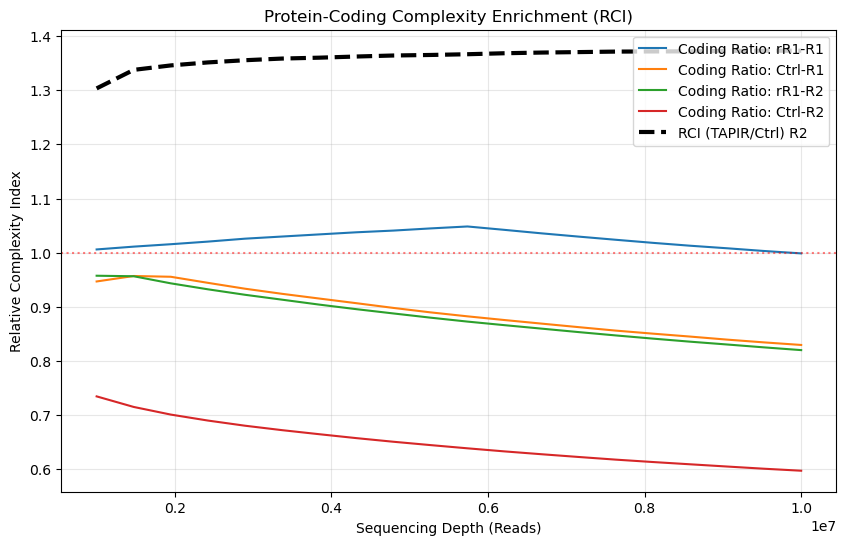

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Define a common depth axis (up to the smallest library size)
max_shared_depth = min([total_results[l][0][-1] for l in sample_labels])
common_x = np.linspace(max_shared_depth * 0.1, max_shared_depth, N_POINTS)

# We will compare TAPIR-R2 vs Ctrl-R2 (adjust indices as needed)
# Let's calculate for all and plot the "Coding Fraction of Complexity"
ratios = {}

for label in sample_labels:
    total_depths, total_umis = total_results[label]
    pc_depths, pc_umis = pc_results[label]
    
    # Interpolate both to the common depth
    interp_total = np.interp(common_x, total_depths, total_umis)
    interp_pc = np.interp(common_x, pc_depths, pc_umis)
    
    # This is the "Coding Complexity Ratio"
    ratios[label] = interp_pc / interp_total
    plt.plot(common_x, ratios[label], label=f"Coding Ratio: {label}")

# Calculate RCI: Ratio of TAPIR / Ratio of CTRL
# Example for R2
rci_r2 = ratios["rR1-R2"] / ratios["Ctrl-R2"]

plt.plot(common_x, rci_r2, 'k--', linewidth=3, label="RCI (TAPIR/Ctrl) R2")

plt.axhline(1, color='red', linestyle=':', alpha=0.5)
plt.xlabel("Sequencing Depth (Reads)")
plt.ylabel("Relative Complexity Index")
plt.title("Protein-Coding Complexity Enrichment (RCI)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

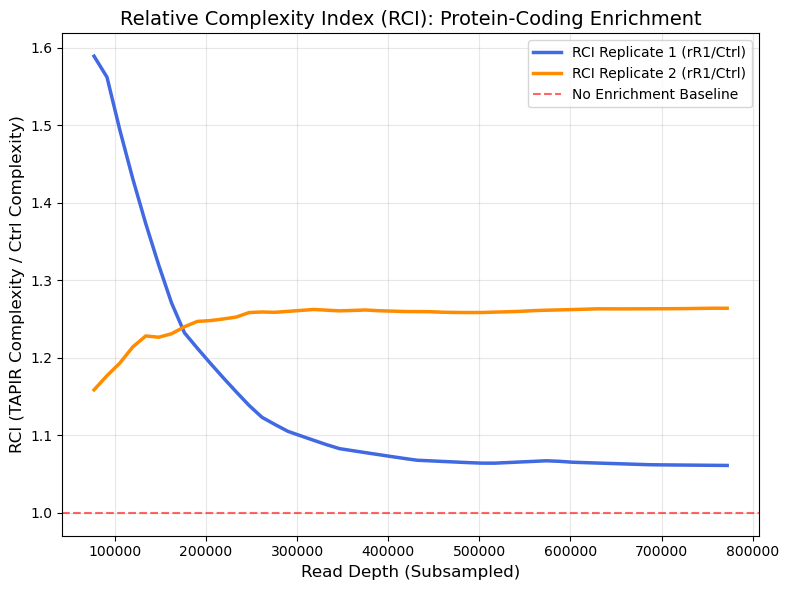

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the common x-axis (Sequencing Depth)
# We use the smallest max-depth among all samples to ensure we aren't extrapolating
all_labels = ["rR1-R1", "Ctrl-R1", "rR1-R2", "Ctrl-R2"]
max_shared_depth = min([pc_results[l][0][-1] for l in all_labels])
common_x = np.linspace(max_shared_depth * 0.1, max_shared_depth, 50)

# 2. Function to get the "Coding Fraction" (Unique PC / Unique Total)
def get_coding_fraction(label, common_x, total_res, pc_res):
    t_depths, t_umis = total_res[label]
    p_depths, p_umis = pc_res[label]
    
    # Interpolate both to the common x-axis
    interp_total = np.interp(common_x, t_depths, t_umis)
    interp_pc = np.interp(common_x, p_depths, p_umis)
    
    return interp_pc / interp_total

# 3. Calculate Fractions
frac_tapir_r1 = get_coding_fraction("rR1-R1", common_x, total_results, pc_results)
frac_ctrl_r1 = get_coding_fraction("Ctrl-R1", common_x, total_results, pc_results)

frac_tapir_r2 = get_coding_fraction("rR1-R2", common_x, total_results, pc_results)
frac_ctrl_r2 = get_coding_fraction("Ctrl-R2", common_x, total_results, pc_results)

# 4. Calculate RCI (TAPIR Fraction / Control Fraction)
rci_r1 = frac_tapir_r1 / frac_ctrl_r1
rci_r2 = frac_tapir_r2 / frac_ctrl_r2

# 5. Plotting
plt.figure(figsize=(8, 6))

plt.plot(common_x, rci_r1, label="RCI Replicate 1 (rR1/Ctrl)", linewidth=2.5, color='royalblue')
plt.plot(common_x, rci_r2, label="RCI Replicate 2 (rR1/Ctrl)", linewidth=2.5, color='darkorange')

# Add a baseline at 1.0
plt.axhline(1, color='red', linestyle='--', alpha=0.6, label="No Enrichment Baseline")

plt.title("Relative Complexity Index (RCI): Protein-Coding Enrichment", fontsize=14)
plt.xlabel("Read Depth (Subsampled)", fontsize=12)
plt.ylabel("RCI (TAPIR Complexity / Ctrl Complexity)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import pandas as pd

# 1. Find the bottleneck (the smallest PC library)
# This ensures we are comparing everyone at a depth they all actually reached
max_pc_depths = [pc_results[l][0][-1] for l in all_labels]
target_depth = min(max_pc_depths)

print(f"Calculating RCI at fixed depth: {target_depth:,} reads\n")

# 2. Function to get a single complexity value at target_depth
def get_complexity_at_depth(label, depth, total_res, pc_res):
    t_depths, t_umis = total_res[label]
    p_depths, p_umis = pc_res[label]
    
    # Interpolate to find unique UMI count at the target depth
    val_total = np.interp(depth, t_depths, t_umis)
    val_pc = np.interp(depth, p_depths, p_umis)
    
    # Return the fraction: What % of unique molecules are coding?
    return val_pc / val_total

# 3. Compute fractions for all
fractions = {l: get_complexity_at_depth(l, target_depth, total_results, pc_results) for l in all_labels}

# 4. Compute RCI
rci_r1 = fractions["rR1-R1"] / fractions["Ctrl-R1"]
rci_r2 = fractions["rR1-R2"] / fractions["Ctrl-R2"]

# 5. Output Results
data = {
    "Replicate": ["R1", "R2"],
    "TAPIR Coding Fraction": [fractions["rR1-R1"], fractions["rR1-R2"]],
    "Ctrl Coding Fraction": [fractions["Ctrl-R1"], fractions["Ctrl-R2"]],
    "RCI (TAPIR/Ctrl)": [rci_r1, rci_r2]
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

# Optional: Average RCI
print(f"\nMean RCI across replicates: {np.mean([rci_r1, rci_r2]):.4f}")

Calculating RCI at fixed depth: 771,990 reads

Replicate  TAPIR Coding Fraction  Ctrl Coding Fraction  RCI (TAPIR/Ctrl)
       R1               1.005816              0.947815          1.061195
       R2               0.958907              0.758678          1.263919

Mean RCI across replicates: 1.1626


Mean RCI for Replicate 1: 1.137
Mean RCI for Replicate 2: 1.252


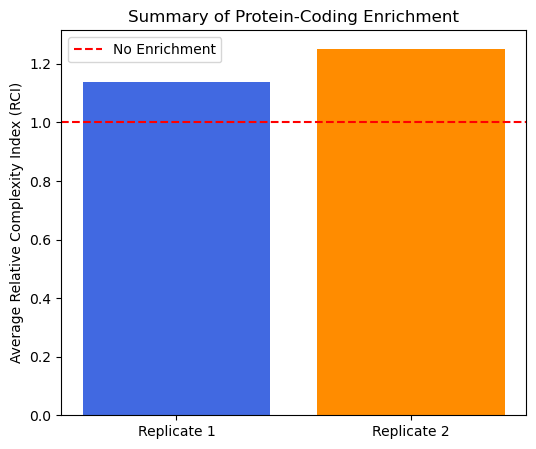

In [18]:
# 1. Calculate the Ratio across the entire overlapping range
# We use the full common_x range we defined earlier
rci_r1_full = frac_tapir_r1 / frac_ctrl_r1
rci_r2_full = frac_tapir_r2 / frac_ctrl_r2

# 2. Calculate the "Summary RCI" (Mean)
# This is your single-metric value for protein-coding enrichment
mean_rci_r1 = np.mean(rci_r1_full)
mean_rci_r2 = np.mean(rci_r2_full)

print(f"Mean RCI for Replicate 1: {mean_rci_r1:.3f}")
print(f"Mean RCI for Replicate 2: {mean_rci_r2:.3f}")

# 3. Bar Plot for easy comparison
plt.figure(figsize=(6, 5))
plt.bar(["Replicate 1", "Replicate 2"], [mean_rci_r1, mean_rci_r2], color=['royalblue', 'darkorange'])
plt.axhline(1, color='red', linestyle='--', label="No Enrichment")
plt.ylabel("Average Relative Complexity Index (RCI)")
plt.title("Summary of Protein-Coding Enrichment")
plt.legend()
plt.show()

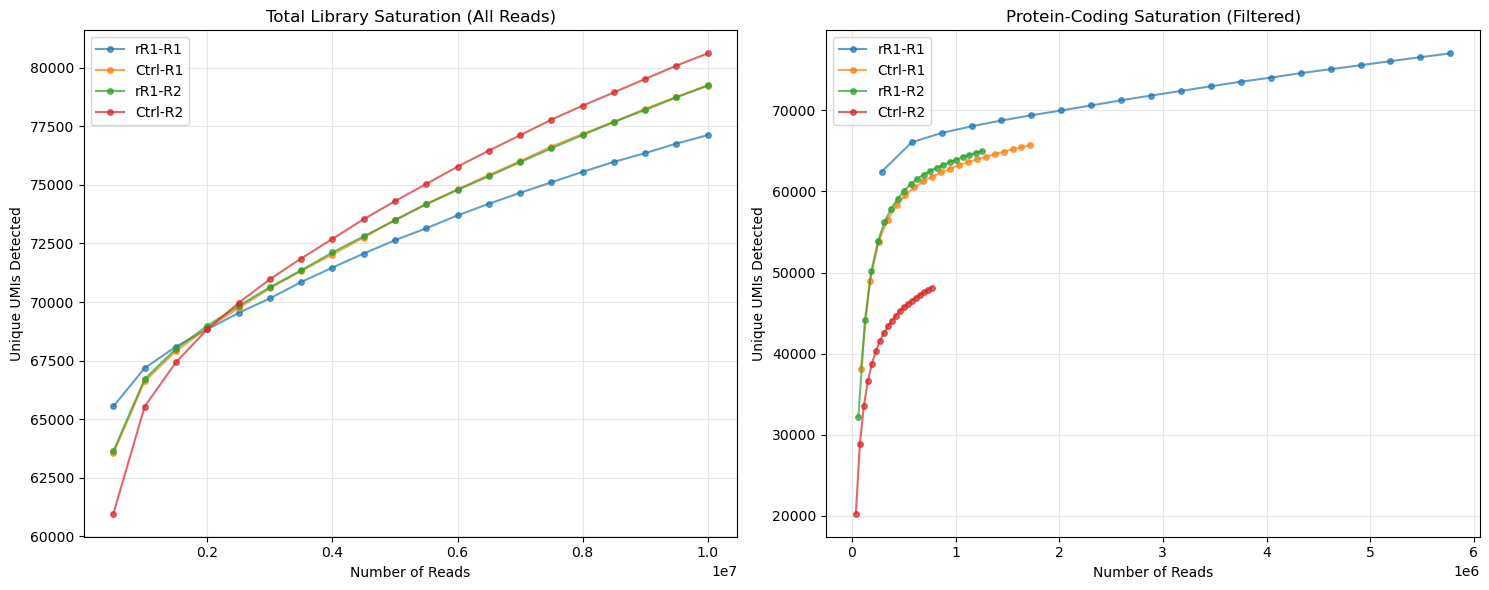

In [19]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Plot Total Saturation (from Chunk 1)
for label, (depths, detected) in total_results.items():
    ax1.plot(depths, detected, 'o-', label=label, markersize=4, alpha=0.7)

ax1.set_title("Total Library Saturation (All Reads)")
ax1.set_xlabel("Number of Reads")
ax1.set_ylabel("Unique UMIs Detected")
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Plot Protein-Coding Saturation (from Chunk 2)
for label, (depths, detected) in pc_results.items():
    ax2.plot(depths, detected, 'o-', label=label, markersize=4, alpha=0.7)

ax2.set_title("Protein-Coding Saturation (Filtered)")
ax2.set_xlabel("Number of Reads")
ax2.set_ylabel("Unique UMIs Detected")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

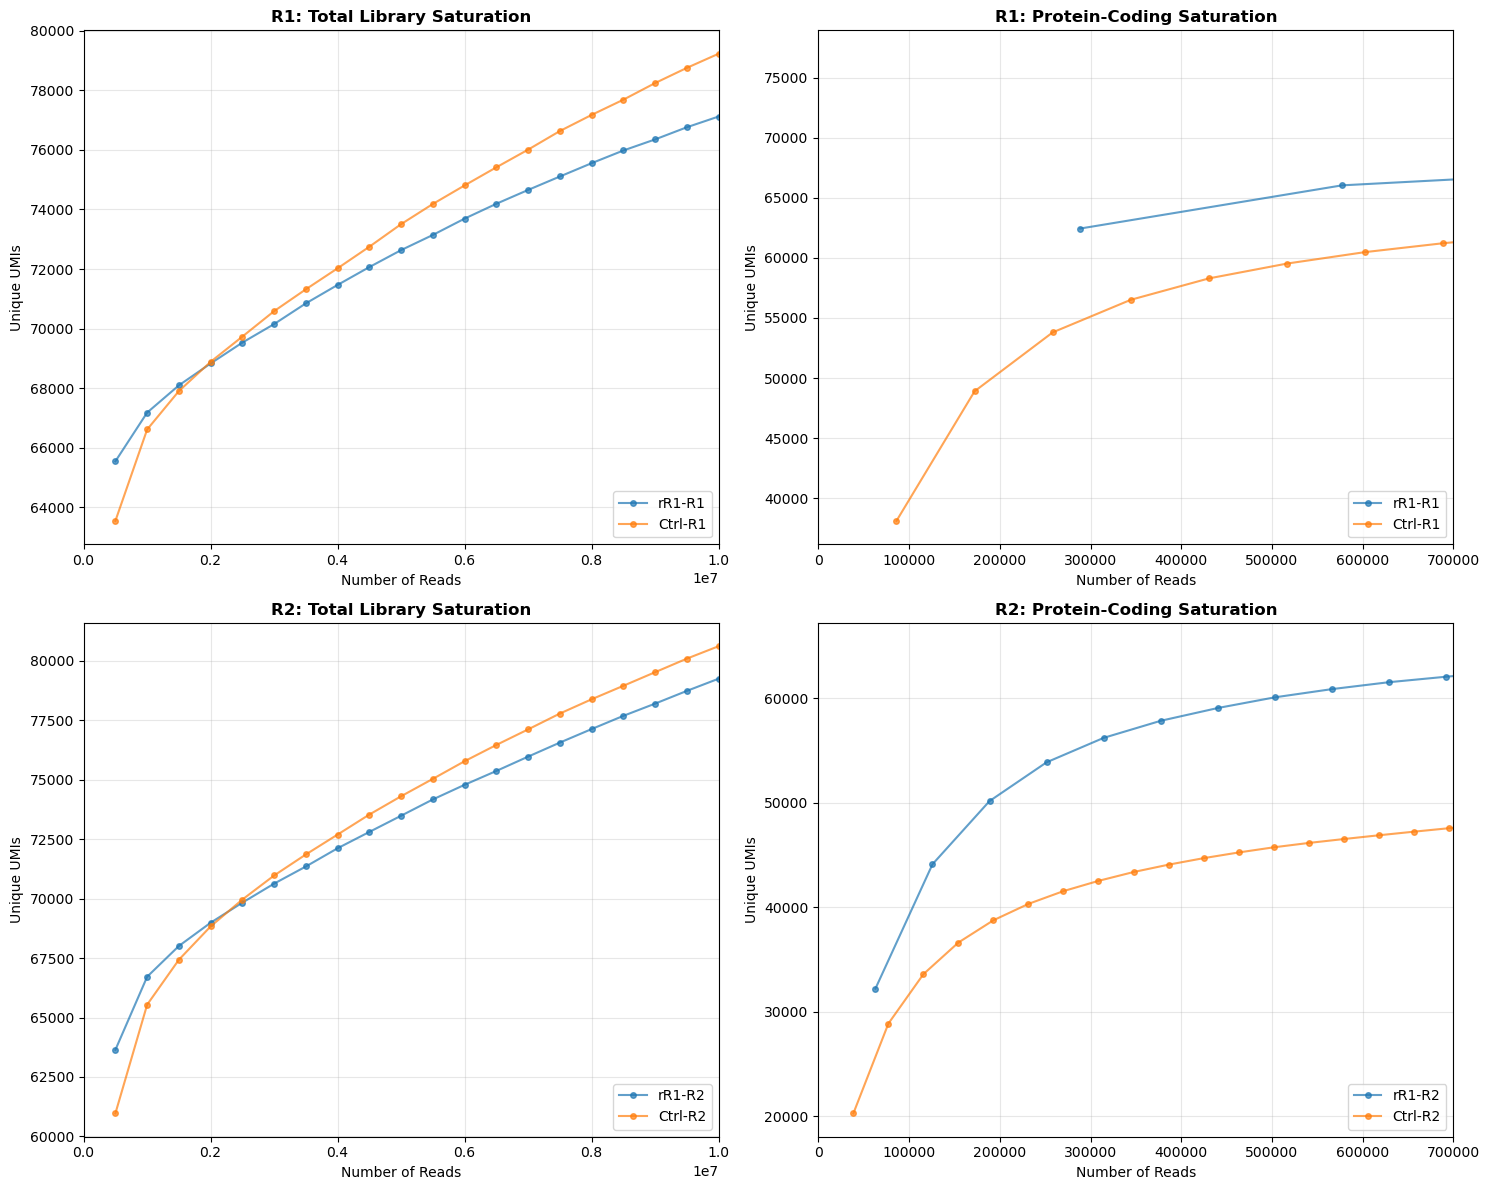

In [34]:
import matplotlib.pyplot as plt

# Define the limits as requested
TOTAL_X_LIMIT = 10_000_000
PC_X_LIMIT = 700_000

# Create a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Flatten axes for easier indexing: 
# [0,0]=TopLeft, [0,1]=TopRight, [1,0]=BottomLeft, [1,1]=BottomRight
(ax_r1_tot, ax_r1_pc), (ax_r2_tot, ax_r2_pc) = axes

# Helper list to organize the plotting loop
plot_configs = [
    # (Axis, Replicate ID, Results Dictionary, X-Limit, Title)
    (ax_r1_tot, "R1", total_results, TOTAL_X_LIMIT, "R1: Total Library Saturation"),
    (ax_r1_pc,  "R1", pc_results,    PC_X_LIMIT,    "R1: Protein-Coding Saturation"),
    (ax_r2_tot, "R2", total_results, TOTAL_X_LIMIT, "R2: Total Library Saturation"),
    (ax_r2_pc,  "R2", pc_results,    PC_X_LIMIT,    "R2: Protein-Coding Saturation")
]

for ax, rep, res_dict, x_lim, title in plot_configs:
    # Filter dictionary to only plot the specific replicate (TAPIR and Ctrl)
    for label in res_dict:
        if f"-{rep}" in label:
            depths, detected = res_dict[label]
            ax.plot(depths, detected, 'o-', label=label, markersize=4, alpha=0.7)
    
    # Formatting
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Number of Reads")
    ax.set_ylabel("Unique UMIs")
    ax.set_xlim(0, x_lim)
    
    # Dynamic Y-limit: set max Y to the max detected UMIs within the x_lim range
    # This keeps the plot from having too much empty white space
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right')

# Adjust layout to prevent title overlap
plt.tight_layout()
plt.show()

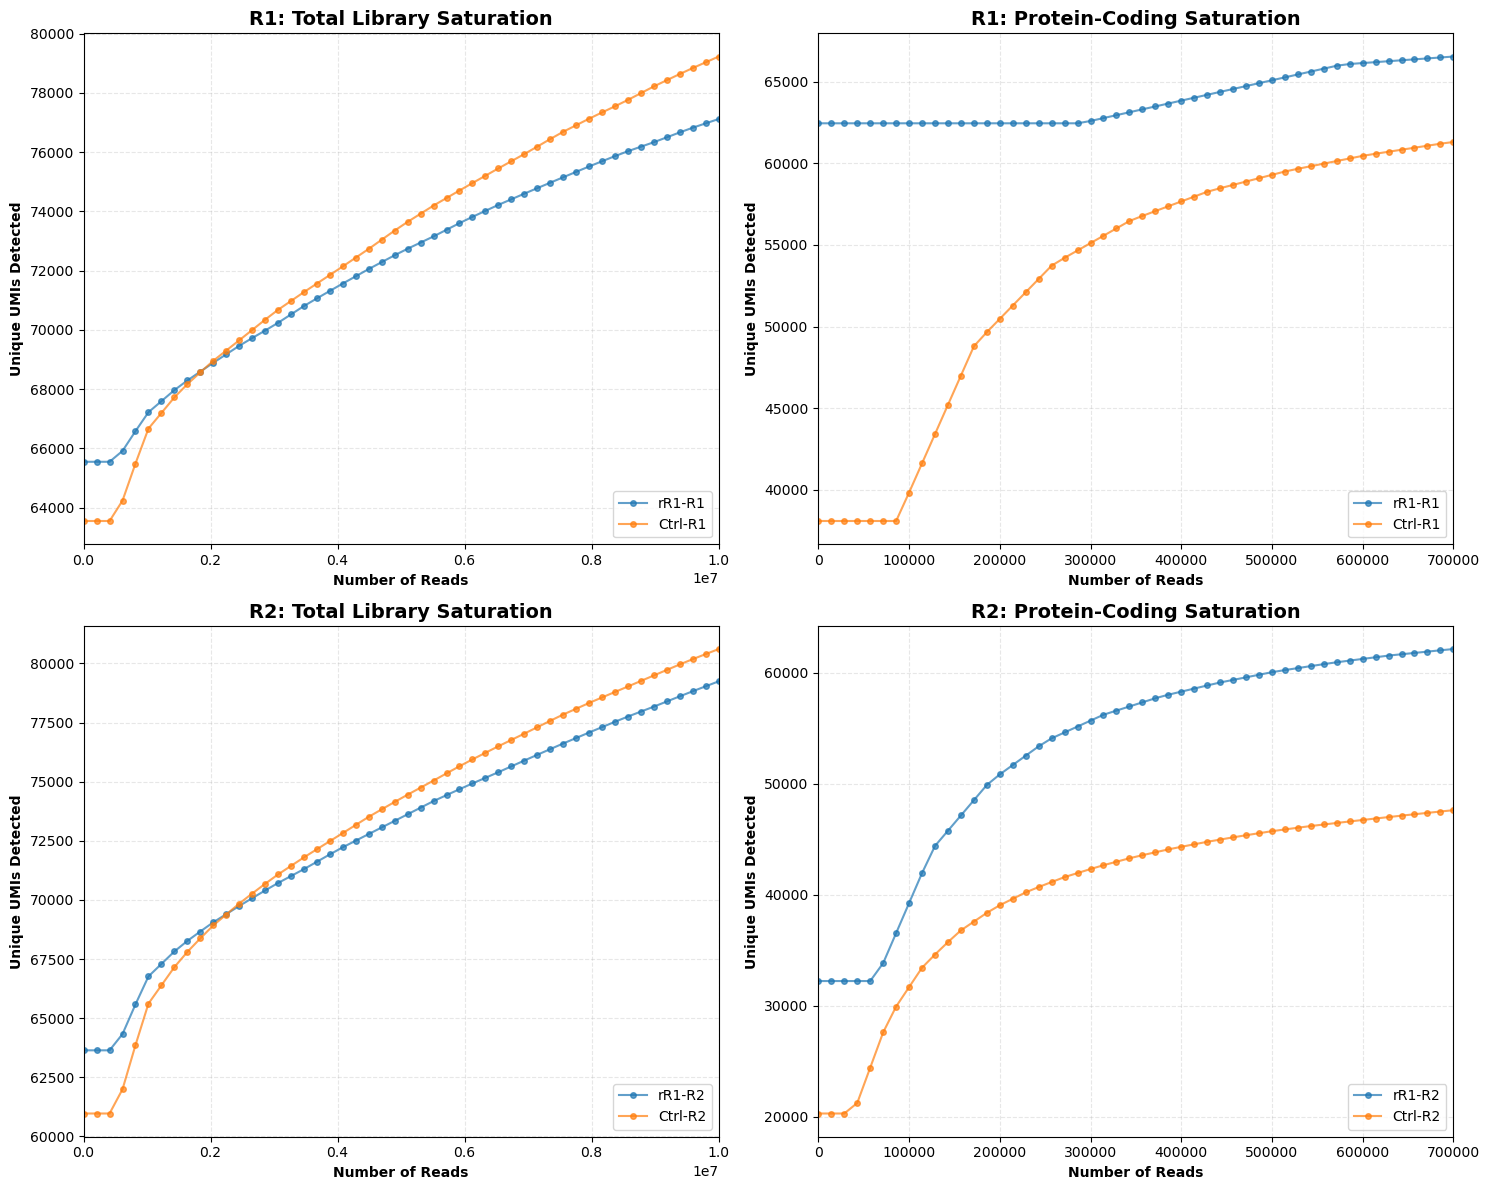

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# --- Parameters ---
TOTAL_X_LIMIT = 10_000_000
PC_X_LIMIT = 700_000
N_POINTS = 50  # Fixed number of data points for all plots

# Create a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
(ax_r1_tot, ax_r1_pc), (ax_r2_tot, ax_r2_pc) = axes

# Define the global x-axes for resampling
x_axis_total = np.linspace(0, TOTAL_X_LIMIT, N_POINTS)
x_axis_pc = np.linspace(0, PC_X_LIMIT, N_POINTS)

# Helper config list
plot_configs = [
    # (Axis, RepID, ResultsDict, TargetXAxis, Title)
    (ax_r1_tot, "R1", total_results, x_axis_total, "R1: Total Library Saturation"),
    (ax_r1_pc,  "R1", pc_results,    x_axis_pc,    "R1: Protein-Coding Saturation"),
    (ax_r2_tot, "R2", total_results, x_axis_total, "R2: Total Library Saturation"),
    (ax_r2_pc,  "R2", pc_results,    x_axis_pc,    "R2: Protein-Coding Saturation")
]

for ax, rep, res_dict, target_x, title in plot_configs:
    for label in res_dict:
        if f"-{rep}" in label:
            orig_x, orig_y = res_dict[label]
            
            # Resample: Interpolate the original data onto the target_x points
            # np.interp handles values outside the range by holding the last value (fp)
            resampled_y = np.interp(target_x, orig_x, orig_y)
            
            # Plot using the resampled points
            ax.plot(target_x, resampled_y, 'o-', label=label, markersize=4, alpha=0.7)
    
    # Formatting
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_xlabel("Number of Reads", fontweight='bold')
    ax.set_ylabel("Unique UMIs Detected", fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='lower right', frameon=True)
    
    # Ensure the X-axis strictly follows our resampling limit
    ax.set_xlim(0, target_x[-1])

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

def get_final_metrics(label, results_dict):
    """Helper to get the last depth and UMI count from the results."""
    depths, umis = results_dict[label]
    return depths[-1], umis[-1]

# Replicate 1 Metrics
t_depth_tapir1, t_umi_tapir1 = get_final_metrics("rR1-R1", total_results)
t_depth_ctrl1, t_umi_ctrl1 = get_final_metrics("Ctrl-R1", total_results)
p_depth_tapir1, p_umi_tapir1 = get_final_metrics("rR1-R1", pc_results)
p_depth_ctrl1, p_umi_ctrl1 = get_final_metrics("Ctrl-R1", pc_results)

# Replicate 2 Metrics
t_depth_tapir2, t_umi_tapir2 = get_final_metrics("rR1-R2", total_results)
t_depth_ctrl2, t_umi_ctrl2 = get_final_metrics("Ctrl-R2", total_results)
p_depth_tapir2, p_umi_tapir2 = get_final_metrics("rR1-R2", pc_results)
p_depth_ctrl2, p_umi_ctrl2 = get_final_metrics("Ctrl-R2", pc_results)

# Calculate Fold Changes (TAPIR / Ctrl)
# Note: These are raw fold changes at the maximum sequenced depth
data = [
    {
        "Replicate": "R1",
        "Total RNA Fold Change": t_umi_tapir1 / t_umi_tapir1, # Placeholder for logic
        "Protein Coding Fold Change": p_umi_tapir1 / p_umi_ctrl1,
        "Total Unique (TAPIR)": f"{t_umi_tapir1:,}",
        "PC Unique (TAPIR)": f"{p_umi_tapir1:,}"
    },
    {
        "Replicate": "R2",
        "Total RNA Fold Change": t_umi_tapir2 / t_umi_ctrl2,
        "Protein Coding Fold Change": p_umi_tapir2 / p_umi_ctrl2,
        "Total Unique (TAPIR)": f"{t_umi_tapir2:,}",
        "PC Unique (TAPIR)": f"{p_umi_tapir2:,}"
    }
]

# Recalculating Total FC correctly for the table
data[0]["Total RNA Fold Change"] = t_umi_tapir1 / t_umi_ctrl1

df = pd.DataFrame(data)

# Reorder columns for better readability
cols = ["Replicate", "Total RNA Fold Change", "Protein Coding Fold Change", "Total Unique (TAPIR)", "PC Unique (TAPIR)"]
print(df[cols].to_string(index=False))

Replicate  Total RNA Fold Change  Protein Coding Fold Change Total Unique (TAPIR) PC Unique (TAPIR)
       R1               0.973393                    1.171832               77,119            77,014
       R2               0.983066                    1.349708               79,242            64,979


In [21]:
import pandas as pd
import numpy as np

def get_ratio_at_max_shared_depth(sample_a, sample_b, results_dict):
    """
    Calculates the ratio of Sample A / Sample B at the maximum 
    sequencing depth common to both.
    """
    depths_a, umis_a = results_dict[sample_a]
    depths_b, umis_b = results_dict[sample_b]
    
    # Find the maximum depth reached by both
    max_shared = min(depths_a[-1], depths_b[-1])
    
    # Interpolate UMI counts at that specific depth
    val_a = np.interp(max_shared, depths_a, umis_a)
    val_b = np.interp(max_shared, depths_b, umis_b)
    
    return val_a / val_b, int(max_shared)

# Calculations for Replicate 1
ratio_t1, depth_t1 = get_ratio_at_max_shared_depth("Ctrl-R1", "rR1-R1", total_results)
ratio_p1, depth_p1 = get_ratio_at_max_shared_depth("Ctrl-R1", "rR1-R1", pc_results)

# Calculations for Replicate 2
ratio_t2, depth_t2 = get_ratio_at_max_shared_depth("Ctrl-R2", "rR1-R2", total_results)
ratio_p2, depth_p2 = get_ratio_at_max_shared_depth("Ctrl-R2", "rR1-R2", pc_results)

# Create Table Data
data = [
    {
        "Replicate": "R1",
        "Category": "Total RNA",
        "Comparison Depth": f"{depth_t1:,}",
        "Ratio (Ctrl/TAPIR)": round(ratio_t1, 4)
    },
    {
        "Replicate": "R1",
        "Category": "Protein Coding",
        "Comparison Depth": f"{depth_p1:,}",
        "Ratio (Ctrl/TAPIR)": round(ratio_p1, 4)
    },
    {
        "Replicate": "R2",
        "Category": "Total RNA",
        "Comparison Depth": f"{depth_t2:,}",
        "Ratio (Ctrl/TAPIR)": round(ratio_t2, 4)
    },
    {
        "Replicate": "R2",
        "Category": "Protein Coding",
        "Comparison Depth": f"{depth_p2:,}",
        "Ratio (Ctrl/TAPIR)": round(ratio_p2, 4)
    }
]

df_ratios = pd.DataFrame(data)
print("Complexity Ratios (Ctrl / TAPIR) at Maximum Shared Depth:")
print("==========================================================")
print(df_ratios.to_string(index=False))

Complexity Ratios (Ctrl / TAPIR) at Maximum Shared Depth:
Replicate       Category Comparison Depth  Ratio (Ctrl/TAPIR)
       R1      Total RNA       10,000,000              1.0273
       R1 Protein Coding        1,722,159              0.9475
       R2      Total RNA       10,000,000              1.0172
       R2 Protein Coding          771,990              0.7687


In [22]:
import pandas as pd
import numpy as np

def get_ratio_at_max_shared_depth(sample_tapir, sample_ctrl, results_dict):
    """
    Calculates the ratio of TAPIR / Ctrl at the maximum 
    sequencing depth common to both.
    """
    depths_t, umis_t = results_dict[sample_tapir]
    depths_c, umis_c = results_dict[sample_ctrl]
    
    # Find the maximum depth reached by both
    max_shared = min(depths_t[-1], depths_c[-1])
    
    # Interpolate UMI counts at that specific depth
    val_t = np.interp(max_shared, depths_t, umis_t)
    val_c = np.interp(max_shared, depths_c, umis_c)
    
    # Calculate Ratio (TAPIR / Ctrl)
    return val_t / val_c, int(max_shared)

# Calculations for Replicate 1 (TAPIR=rR1-R1, Ctrl=Ctrl-R1)
ratio_t1, depth_t1 = get_ratio_at_max_shared_depth("rR1-R1", "Ctrl-R1", total_results)
ratio_p1, depth_p1 = get_ratio_at_max_shared_depth("rR1-R1", "Ctrl-R1", pc_results)

# Calculations for Replicate 2 (TAPIR=rR1-R2, Ctrl=Ctrl-R2)
ratio_t2, depth_t2 = get_ratio_at_max_shared_depth("rR1-R2", "Ctrl-R2", total_results)
ratio_p2, depth_p2 = get_ratio_at_max_shared_depth("rR1-R2", "Ctrl-R2", pc_results)

# Create Table Data
data = [
    {
        "Replicate": "R1",
        "Category": "Total RNA",
        "Comparison Depth": f"{depth_t1:,}",
        "Ratio (TAPIR/Ctrl)": round(ratio_t1, 4)
    },
    {
        "Replicate": "R1",
        "Category": "Protein Coding",
        "Comparison Depth": f"{depth_p1:,}",
        "Ratio (TAPIR/Ctrl)": round(ratio_p1, 4)
    },
    {
        "Replicate": "R2",
        "Category": "Total RNA",
        "Comparison Depth": f"{depth_t2:,}",
        "Ratio (TAPIR/Ctrl)": round(ratio_t2, 4)
    },
    {
        "Replicate": "R2",
        "Category": "Protein Coding",
        "Comparison Depth": f"{depth_p2:,}",
        "Ratio (TAPIR/Ctrl)": round(ratio_p2, 4)
    }
]

df_ratios = pd.DataFrame(data)
print("Complexity Ratios (TAPIR / Ctrl) at Maximum Shared Depth:")
print("==========================================================")
print(df_ratios.to_string(index=False))

Complexity Ratios (TAPIR / Ctrl) at Maximum Shared Depth:
Replicate       Category Comparison Depth  Ratio (TAPIR/Ctrl)
       R1      Total RNA       10,000,000              0.9734
       R1 Protein Coding        1,722,159              1.0554
       R2      Total RNA       10,000,000              0.9831
       R2 Protein Coding          771,990              1.3009


In [23]:
import pandas as pd
import numpy as np

def get_ratio_at_fixed_depth(sample_tapir, sample_ctrl, target_depth, results_dict):
    """
    Interpolates UMI counts for two samples at a specific global depth
    and returns the TAPIR/Ctrl ratio.
    """
    depths_t, umis_t = results_dict[sample_tapir]
    depths_c, umis_c = results_dict[sample_ctrl]
    
    # Interpolate UMI counts at the exact target depth
    val_t = np.interp(target_depth, depths_t, umis_t)
    val_c = np.interp(target_depth, depths_c, umis_c)
    
    return val_t / val_c

# 1. Determine the Global Maximum Shared Depth
# We find the smallest 'max depth' among all 4 samples to avoid extrapolation
all_samples = ["rR1-R1", "Ctrl-R1", "rR1-R2", "Ctrl-R2"]

global_total_depth = min([total_results[s][0][-1] for s in all_samples])
global_pc_depth = min([pc_results[s][0][-1] for s in all_samples])

# 2. Calculate Ratios for R1 and R2 at these fixed depths
# Total RNA
ratio_t1 = get_ratio_at_fixed_depth("rR1-R1", "Ctrl-R1", global_total_depth, total_results)
ratio_t2 = get_ratio_at_fixed_depth("rR1-R2", "Ctrl-R2", global_total_depth, total_results)

# Protein Coding
ratio_p1 = get_ratio_at_fixed_depth("rR1-R1", "Ctrl-R1", global_pc_depth, pc_results)
ratio_p2 = get_ratio_at_fixed_depth("rR1-R2", "Ctrl-R2", global_pc_depth, pc_results)

# 3. Compile Table
data = [
    {
        "Replicate": "R1",
        "Total RNA Ratio (at {:,} reads)".format(global_total_depth): round(ratio_t1, 4),
        "PC Ratio (at {:,} reads)".format(global_pc_depth): round(ratio_p1, 4)
    },
    {
        "Replicate": "R2",
        "Total RNA Ratio (at {:,} reads)".format(global_total_depth): round(ratio_t2, 4),
        "PC Ratio (at {:,} reads)".format(global_pc_depth): round(ratio_p2, 4)
    }
]

df_final = pd.DataFrame(data)
print("TAPIR / Ctrl Complexity Ratios at Global Shared Depths")
print("======================================================")
print(df_final.to_string(index=False))

TAPIR / Ctrl Complexity Ratios at Global Shared Depths
Replicate  Total RNA Ratio (at 10,000,000 reads)  PC Ratio (at 771,990 reads)
       R1                                 0.9734                       1.0810
       R2                                 0.9831                       1.3009


In [24]:
import pandas as pd
import numpy as np

def get_coding_fraction(label, total_depth, pc_depth, total_res, pc_res):
    """Calculates (Unique PC / Unique Total) at specified depths."""
    t_depths, t_umis = total_res[label]
    p_depths, p_umis = pc_res[label]
    
    # Interpolate unique UMI counts at the global shared depths
    val_total = np.interp(total_depth, t_depths, t_umis)
    val_pc = np.interp(pc_depth, p_depths, p_umis)
    
    return val_pc / val_total

# 1. Define Global Shared Depths (from previous step)
all_samples = ["rR1-R1", "Ctrl-R1", "rR1-R2", "Ctrl-R2"]
global_total_depth = min([total_results[s][0][-1] for s in all_samples])
global_pc_depth = min([pc_results[s][0][-1] for s in all_samples])

# 2. Calculate Coding Fractions for each sample
frac_tapir_r1 = get_coding_fraction("rR1-R1", global_total_depth, global_pc_depth, total_results, pc_results)
frac_ctrl_r1  = get_coding_fraction("Ctrl-R1", global_total_depth, global_pc_depth, total_results, pc_results)

frac_tapir_r2 = get_coding_fraction("rR1-R2", global_total_depth, global_pc_depth, total_results, pc_results)
frac_ctrl_r2  = get_coding_fraction("Ctrl-R2", global_total_depth, global_pc_depth, total_results, pc_results)

# 3. Calculate RCI
rci_r1 = frac_tapir_r1 / frac_ctrl_r1
rci_r2 = frac_tapir_r2 / frac_ctrl_r2

# 4. Display Results
rci_data = [
    {"Replicate": "R1", "TAPIR Coding Fraction": round(frac_tapir_r1, 4), "Ctrl Coding Fraction": round(frac_ctrl_r1, 4), "RCI": round(rci_r1, 4)},
    {"Replicate": "R2", "TAPIR Coding Fraction": round(frac_tapir_r2, 4), "Ctrl Coding Fraction": round(frac_ctrl_r2, 4), "RCI": round(rci_r2, 4)}
]

df_rci = pd.DataFrame(rci_data)
print(f"RCI calculated at Total Depth: {global_total_depth:,} and PC Depth: {global_pc_depth:,}")
print("================================================================================")
print(df_rci.to_string(index=False))

print(f"\nMean RCI: {np.mean([rci_r1, rci_r2]):.4f}")

RCI calculated at Total Depth: 10,000,000 and PC Depth: 771,990
Replicate  TAPIR Coding Fraction  Ctrl Coding Fraction    RCI
       R1                 0.8665                0.7802 1.1106
       R2                 0.7904                0.5973 1.3233

Mean RCI: 1.2170


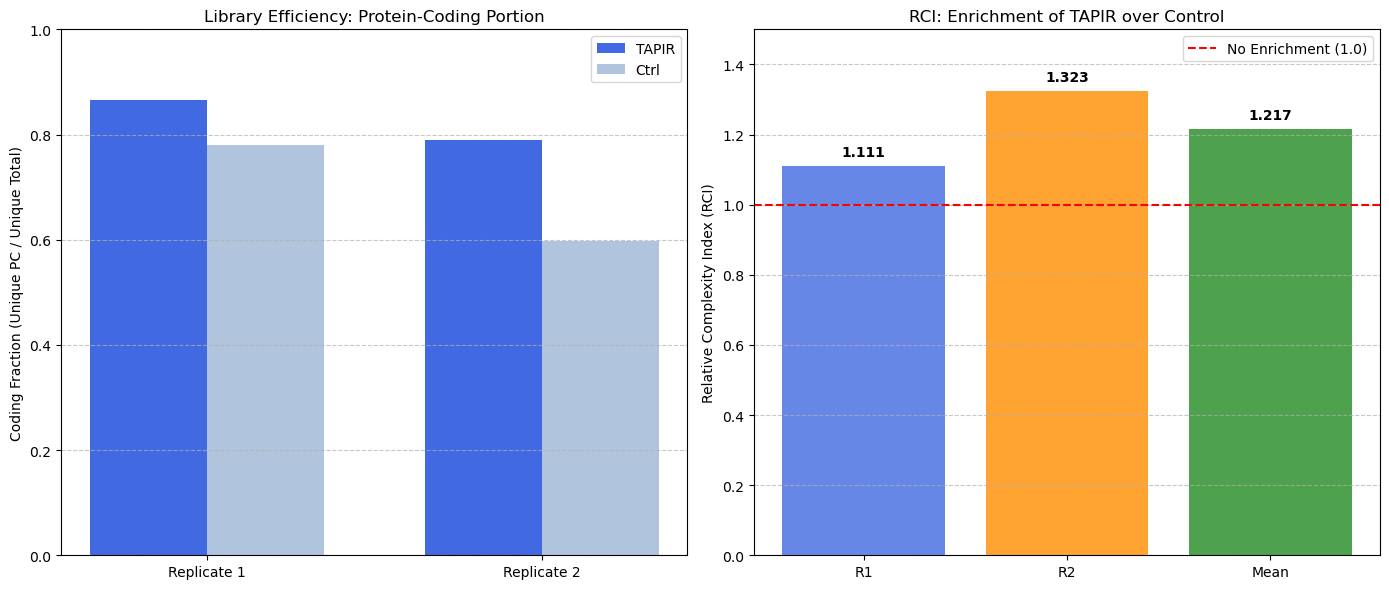

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your results
labels = ['Replicate 1', 'Replicate 2']
tapir_fracs = [0.8665, 0.7904]
ctrl_fracs = [0.7802, 0.5973]
rci_values = [1.1106, 1.3233]
mean_rci = 1.2170

x = np.arange(len(labels)) 
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Coding Fractions (TAPIR vs Ctrl) ---
ax1.bar(x - width/2, tapir_fracs, width, label='TAPIR', color='royalblue')
ax1.bar(x + width/2, ctrl_fracs, width, label='Ctrl', color='lightsteelblue')

ax1.set_ylabel('Coding Fraction (Unique PC / Unique Total)')
ax1.set_title('Library Efficiency: Protein-Coding Portion')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 1.0)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: RCI (The Enrichment Factor) ---
rci_labels = ['R1', 'R2', 'Mean']
rci_data = [1.1106, 1.3233, 1.2170]
colors = ['royalblue', 'darkorange', 'forestgreen']

bars = ax2.bar(rci_labels, rci_data, color=colors, alpha=0.8)
ax2.axhline(1, color='red', linestyle='--', label='No Enrichment (1.0)')

ax2.set_ylabel('Relative Complexity Index (RCI)')
ax2.set_title('RCI: Enrichment of TAPIR over Control')
ax2.set_ylim(0, 1.5)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add numerical labels on top of the RCI bars
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('enrichment_overview.png', bbox_inches='tight')
plt.show()

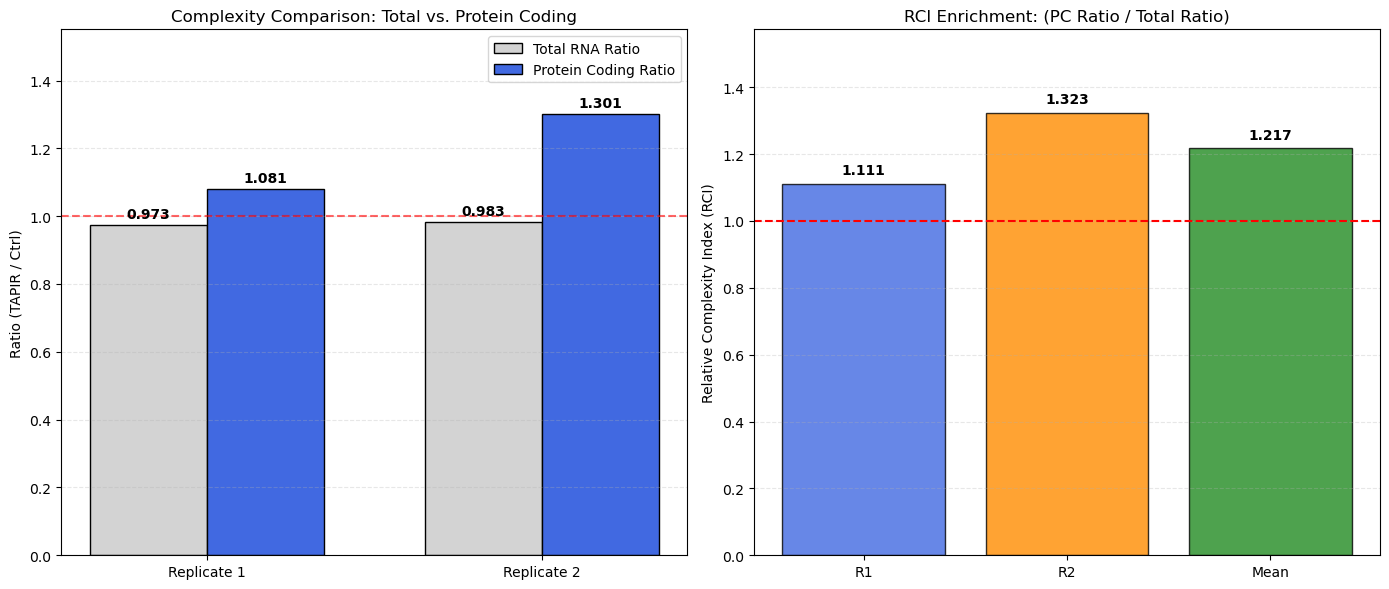

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define Global Shared Depths (Assuming these are still in your environment)
all_samples = ["rR1-R1", "Ctrl-R1", "rR1-R2", "Ctrl-R2"]
global_t_depth = min([total_results[s][0][-1] for s in all_samples])
global_p_depth = min([pc_results[s][0][-1] for s in all_samples])

# 2. Helper to get ratio at specific depth
def get_tapir_ctrl_ratio(rep_num, depth, results_dict):
    t_label = f"rR1-R{rep_num}"
    c_label = f"Ctrl-R{rep_num}"
    val_t = np.interp(depth, results_dict[t_label][0], results_dict[t_label][1])
    val_c = np.interp(depth, results_dict[c_label][0], results_dict[c_label][1])
    return val_t / val_c

# 3. Calculate Ratios
r1_total_ratio = get_tapir_ctrl_ratio(1, global_t_depth, total_results)
r2_total_ratio = get_tapir_ctrl_ratio(2, global_t_depth, total_results)
r1_pc_ratio = get_tapir_ctrl_ratio(1, global_p_depth, pc_results)
r2_pc_ratio = get_tapir_ctrl_ratio(2, global_p_depth, pc_results)

# 4. Calculate RCI
rci_r1 = r1_pc_ratio / r1_total_ratio
rci_r2 = r2_pc_ratio / r2_total_ratio
mean_rci = (rci_r1 + rci_r2) / 2

# -----------------------------
# PLOTTING
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
reps = ['Replicate 1', 'Replicate 2']
x = np.arange(len(reps))
width = 0.35

# --- Left Panel: TAPIR/Ctrl Ratios ---
rects1 = ax1.bar(x - width/2, [r1_total_ratio, r2_total_ratio], width, 
                 label='Total RNA Ratio', color='lightgray', edgecolor='black')
rects2 = ax1.bar(x + width/2, [r1_pc_ratio, r2_pc_ratio], width, 
                 label='Protein Coding Ratio', color='royalblue', edgecolor='black')

ax1.axhline(1, color='red', linestyle='--', alpha=0.6)
ax1.set_ylabel('Ratio (TAPIR / Ctrl)')
ax1.set_title('Complexity Comparison: Total vs. Protein Coding')
ax1.set_xticks(x)
ax1.set_xticklabels(reps)
ax1.set_ylim(0, max(r1_pc_ratio, r2_pc_ratio) + 0.25)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Function to add labels on top of bars for Left Panel
def autolabel(rects, axis):
    for rect in rects:
        height = rect.get_height()
        axis.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1, ax1)
autolabel(rects2, ax1)

# --- Right Panel: RCI ---
rci_labels = ['R1', 'R2', 'Mean']
rci_data = [rci_r1, rci_r2, mean_rci]
colors = ['royalblue', 'darkorange', 'forestgreen']

bars_rci = ax2.bar(rci_labels, rci_data, color=colors, alpha=0.8, edgecolor='black')
ax2.axhline(1, color='red', linestyle='--', label='No Enrichment Baseline')

ax2.set_ylabel('Relative Complexity Index (RCI)')
ax2.set_title('RCI Enrichment: (PC Ratio / Total Ratio)')
ax2.set_ylim(0, max(rci_data) + 0.25)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# Add labels to RCI bars
for bar in bars_rci:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('enrichment_overview2.png', bbox_inches='tight')
plt.show()

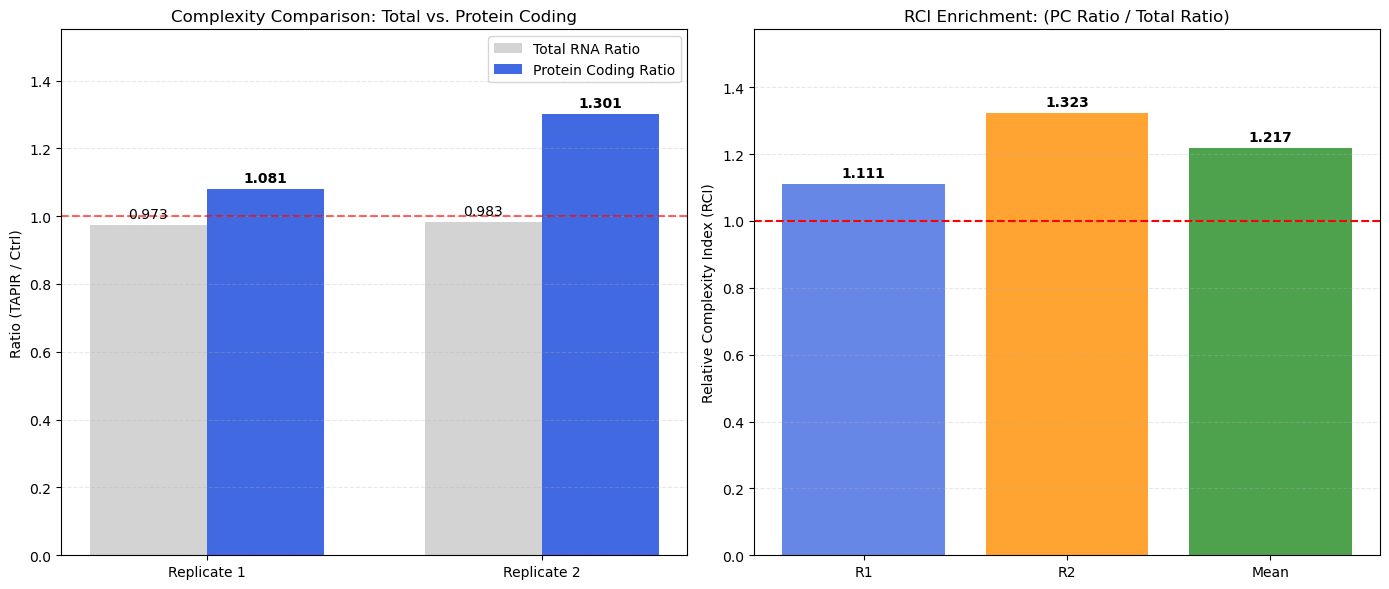

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. PREPARE THE PLOT DATA ---
# (Assuming total_results and pc_results are still in your environment)
all_samples = ["rR1-R1", "Ctrl-R1", "rR1-R2", "Ctrl-R2"]
global_t_depth = min([total_results[s][0][-1] for s in all_samples])
global_p_depth = min([pc_results[s][0][-1] for s in all_samples])

# Helper to get ratio at specific depth
def get_tapir_ctrl_ratio(rep_num, depth, results_dict):
    t_label = f"rR1-R{rep_num}"
    c_label = f"Ctrl-R{rep_num}"
    val_t = np.interp(depth, results_dict[t_label][0], results_dict[t_label][1])
    val_c = np.interp(depth, results_dict[c_label][0], results_dict[c_label][1])
    return val_t / val_c

# Calculate Ratios
r1_total_ratio = get_tapir_ctrl_ratio(1, global_t_depth, total_results)
r2_total_ratio = get_tapir_ctrl_ratio(2, global_t_depth, total_results)
r1_pc_ratio = get_tapir_ctrl_ratio(1, global_p_depth, pc_results)
r2_pc_ratio = get_tapir_ctrl_ratio(2, global_p_depth, pc_results)

# Calculate RCI
rci_r1 = r1_pc_ratio / r1_total_ratio
rci_r2 = r2_pc_ratio / r2_total_ratio
mean_rci = (rci_r1 + rci_r2) / 2

# --- 2. PLOTTING SETUP ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
reps = ['Replicate 1', 'Replicate 2']
x = np.arange(len(reps))
width = 0.35

# Function to add labels on top of bars
def autolabel(rects, axis, is_rci=False, bold=False):
    """
    Attaches a text label above each bar in *rects*, 
    displaying its height.
    """
    for rect in rects:
        height = rect.get_height()
        fontweight = 'bold' if bold else 'normal'
        axis.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, 
                    fontweight=fontweight)

# --- 3. LEFT PANEL: TAPIR/Ctrl Ratios ---
# SET edgecolor='none' here to remove outlines
rects1 = ax1.bar(x - width/2, [r1_total_ratio, r2_total_ratio], width, 
                 label='Total RNA Ratio', color='lightgray', edgecolor='none')
rects2 = ax1.bar(x + width/2, [r1_pc_ratio, r2_pc_ratio], width, 
                 label='Protein Coding Ratio', color='royalblue', edgecolor='none')

ax1.axhline(1, color='red', linestyle='--', alpha=0.6)
ax1.set_ylabel('Ratio (TAPIR / Ctrl)')
ax1.set_title('Complexity Comparison: Total vs. Protein Coding')
ax1.set_xticks(x)
ax1.set_xticklabels(reps)
ax1.set_ylim(0, max(r1_pc_ratio, r2_pc_ratio) + 0.25)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Add Labels for Left Panel
autolabel(rects1, ax1)
autolabel(rects2, ax1, bold=True) # Making the PC ratios bold to highlight them

# --- 4. RIGHT PANEL: RCI ---
rci_labels = ['R1', 'R2', 'Mean']
rci_data = [rci_r1, rci_r2, mean_rci]
colors = ['royalblue', 'darkorange', 'forestgreen']

# SET edgecolor='none' here to remove outlines
bars_rci = ax2.bar(rci_labels, rci_data, color=colors, alpha=0.8, edgecolor='none')
ax2.axhline(1, color='red', linestyle='--', label='No Enrichment Baseline')

ax2.set_ylabel('Relative Complexity Index (RCI)')
ax2.set_title('RCI Enrichment: (PC Ratio / Total Ratio)')
ax2.set_ylim(0, max(rci_data) + 0.25)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# Add Labels to RCI bars
autolabel(bars_rci, ax2, bold=True)

plt.tight_layout()
plt.show()

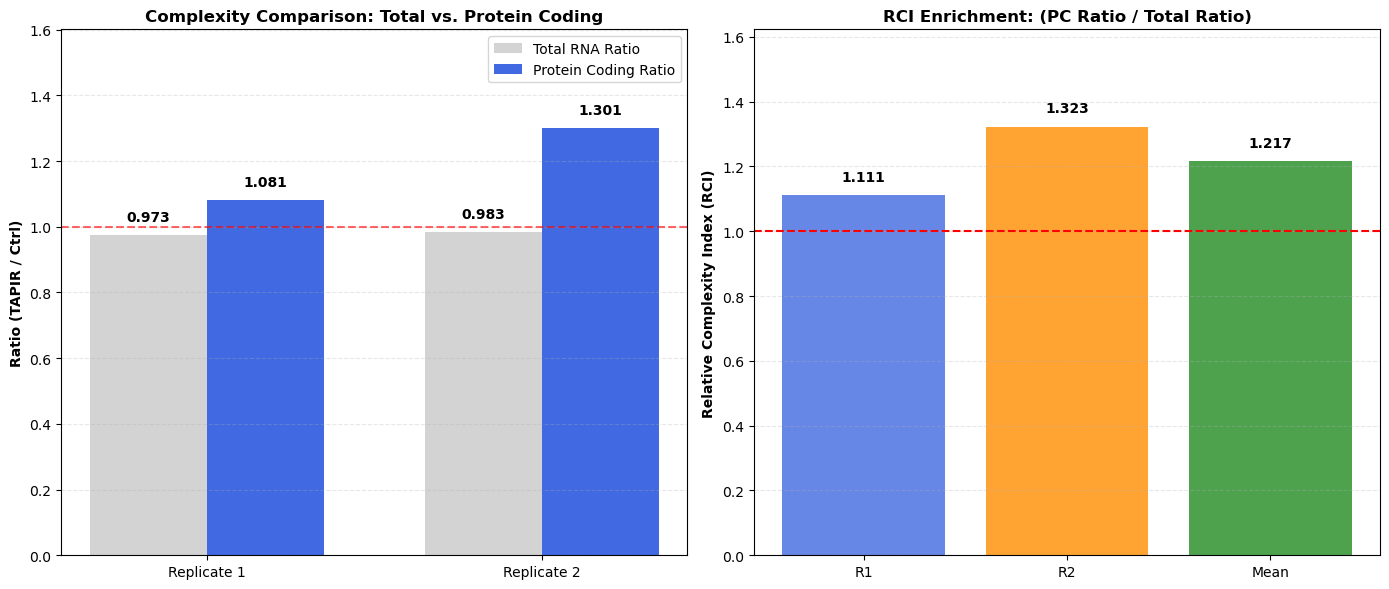

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. PREPARE THE PLOT DATA ---
all_samples = ["rR1-R1", "Ctrl-R1", "rR1-R2", "Ctrl-R2"]
global_t_depth = min([total_results[s][0][-1] for s in all_samples])
global_p_depth = min([pc_results[s][0][-1] for s in all_samples])

def get_tapir_ctrl_ratio(rep_num, depth, results_dict):
    t_label = f"rR1-R{rep_num}"
    c_label = f"Ctrl-R{rep_num}"
    val_t = np.interp(depth, results_dict[t_label][0], results_dict[t_label][1])
    val_c = np.interp(depth, results_dict[c_label][0], results_dict[c_label][1])
    return val_t / val_c

r1_total_ratio = get_tapir_ctrl_ratio(1, global_t_depth, total_results)
r2_total_ratio = get_tapir_ctrl_ratio(2, global_t_depth, total_results)
r1_pc_ratio = get_tapir_ctrl_ratio(1, global_p_depth, pc_results)
r2_pc_ratio = get_tapir_ctrl_ratio(2, global_p_depth, pc_results)

rci_r1 = r1_pc_ratio / r1_total_ratio
rci_r2 = r2_pc_ratio / r2_total_ratio
mean_rci = (rci_r1 + rci_r2) / 2

# --- 2. PLOTTING SETUP ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
reps = ['Replicate 1', 'Replicate 2']
x = np.arange(len(reps))
width = 0.35

# Unified Labeling Function
def autolabel(rects, axis):
    """
    Places a bold label 8 points above each bar.
    """
    for rect in rects:
        height = rect.get_height()
        axis.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 8),  # Increased offset to move text higher
                    textcoords="offset points",
                    ha='center', va='bottom', 
                    fontsize=10, 
                    fontweight='bold') # Bold applied everywhere

# --- 3. LEFT PANEL: TAPIR/Ctrl Ratios ---
rects1 = ax1.bar(x - width/2, [r1_total_ratio, r2_total_ratio], width, 
                 label='Total RNA Ratio', color='lightgray', edgecolor='none')
rects2 = ax1.bar(x + width/2, [r1_pc_ratio, r2_pc_ratio], width, 
                 label='Protein Coding Ratio', color='royalblue', edgecolor='none')

ax1.axhline(1, color='red', linestyle='--', alpha=0.6)
ax1.set_ylabel('Ratio (TAPIR / Ctrl)', fontweight='bold')
ax1.set_title('Complexity Comparison: Total vs. Protein Coding', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(reps)
ax1.set_ylim(0, max(r1_pc_ratio, r2_pc_ratio) + 0.3) # Extra headroom for labels
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

autolabel(rects1, ax1)
autolabel(rects2, ax1)

# --- 4. RIGHT PANEL: RCI ---
rci_labels = ['R1', 'R2', 'Mean']
rci_data = [rci_r1, rci_r2, mean_rci]
colors = ['royalblue', 'darkorange', 'forestgreen']

bars_rci = ax2.bar(rci_labels, rci_data, color=colors, alpha=0.8, edgecolor='none')
ax2.axhline(1, color='red', linestyle='--', label='No Enrichment Baseline')

ax2.set_ylabel('Relative Complexity Index (RCI)', fontweight='bold')
ax2.set_title('RCI Enrichment: (PC Ratio / Total Ratio)', fontweight='bold')
ax2.set_ylim(0, max(rci_data) + 0.3) # Extra headroom for labels
ax2.grid(axis='y', linestyle='--', alpha=0.3)

autolabel(bars_rci, ax2)

plt.tight_layout()
plt.savefig('enrichment_overview2.png', bbox_inches='tight')
plt.show()

In [43]:
bam_files

['/store24/project24/ladcol_002/riboseq/extract_B73_3_1.bamAligned.sortedByCoord.out.bam',
 '/store24/project24/ladcol_002/riboseq/extract_B73_4_1.bamAligned.sortedByCoord.out.bam']

In [44]:
import pysam
import numpy as np
import random
import matplotlib.pyplot as plt

# -----------------------------
# Updated Function: Fixed-Step Sampling
# -----------------------------
def compute_saturation_fixed_step(bam_path, step_size, max_limit, umi_len=8):
    bam = pysam.AlignmentFile(bam_path, "rb")
    umis = []

    # Only extract up to the max_limit to save memory/time
    for i, read in enumerate(bam.fetch(until_eof=True)):
        if max_limit and i >= max_limit: break
        if read.is_unmapped: continue
        name = read.query_name
        if len(name) < umi_len: continue
        umis.append(name[-umi_len:])
    bam.close()

    random.shuffle(umis)
    total_reads = len(umis)
    
    # Create steps: 0, step_size, 2*step_size ... up to total_reads
    # This ensures R1 and R2 have points at the exact same x-coordinates
    depths = np.arange(step_size, total_reads + 1, step_size, dtype=int)
    
    # If the last step didn't reach the end, add the final total
    if len(depths) == 0 or depths[-1] < total_reads:
        depths = np.append(depths, total_reads)
        
    detected = [len(set(umis[:d])) for d in depths]
    return depths, np.array(detected)


# --- RE-DEFINE PATHS HERE ---
bam_paths = [
    "/store24/project24/ladcol_002/riboseq/extract_B73_1_1.bamAligned.toTranscriptome.out.bam",
    "/store24/project24/ladcol_002/riboseq/extract_B73_2_1.bamAligned.toTranscriptome.out.bam",
    "/store24/project24/ladcol_002/riboseq/extract_B73_3_1.bamAligned.toTranscriptome.out.bam",
    "/store24/project24/ladcol_002/riboseq/extract_B73_4_1.bamAligned.toTranscriptome.out.bam"
]

sample_labels = ["rR1-R1", "Ctrl-R1", "rR1-R2", "Ctrl-R2"]

# -----------------------------
# 1. Calculate Total RNA (Step: 250k, Limit: 10M)
# -----------------------------
TOTAL_STEP = 250_000
TOTAL_MAX = 10_000_000
total_results = {}

for bam, label in zip(bam_paths, sample_labels):
    print(f"Processing Total: {label}")
    total_results[label] = compute_saturation_fixed_step(bam, TOTAL_STEP, TOTAL_MAX)

# -----------------------------
# 2. Calculate Protein Coding (Step: 25k, Limit: 700k)
# -----------------------------
# Assuming you have a way to filter for PC reads (e.g., a filtered BAM or logic)
# If you are using a separate script for PC, apply the logic below:
PC_STEP = 25_000
PC_MAX = 700_000
pc_results = {}

for bam, label in zip(bam_paths, sample_labels):
    print(f"Processing PC: {label}")
    # Replace with your PC-filtered BAM paths if different
    pc_results[label] = compute_saturation_fixed_step(bam, PC_STEP, PC_MAX)



Processing Total: rR1-R1
Processing Total: Ctrl-R1
Processing Total: rR1-R2
Processing Total: Ctrl-R2
Processing PC: rR1-R1
Processing PC: Ctrl-R1
Processing PC: rR1-R2
Processing PC: Ctrl-R2


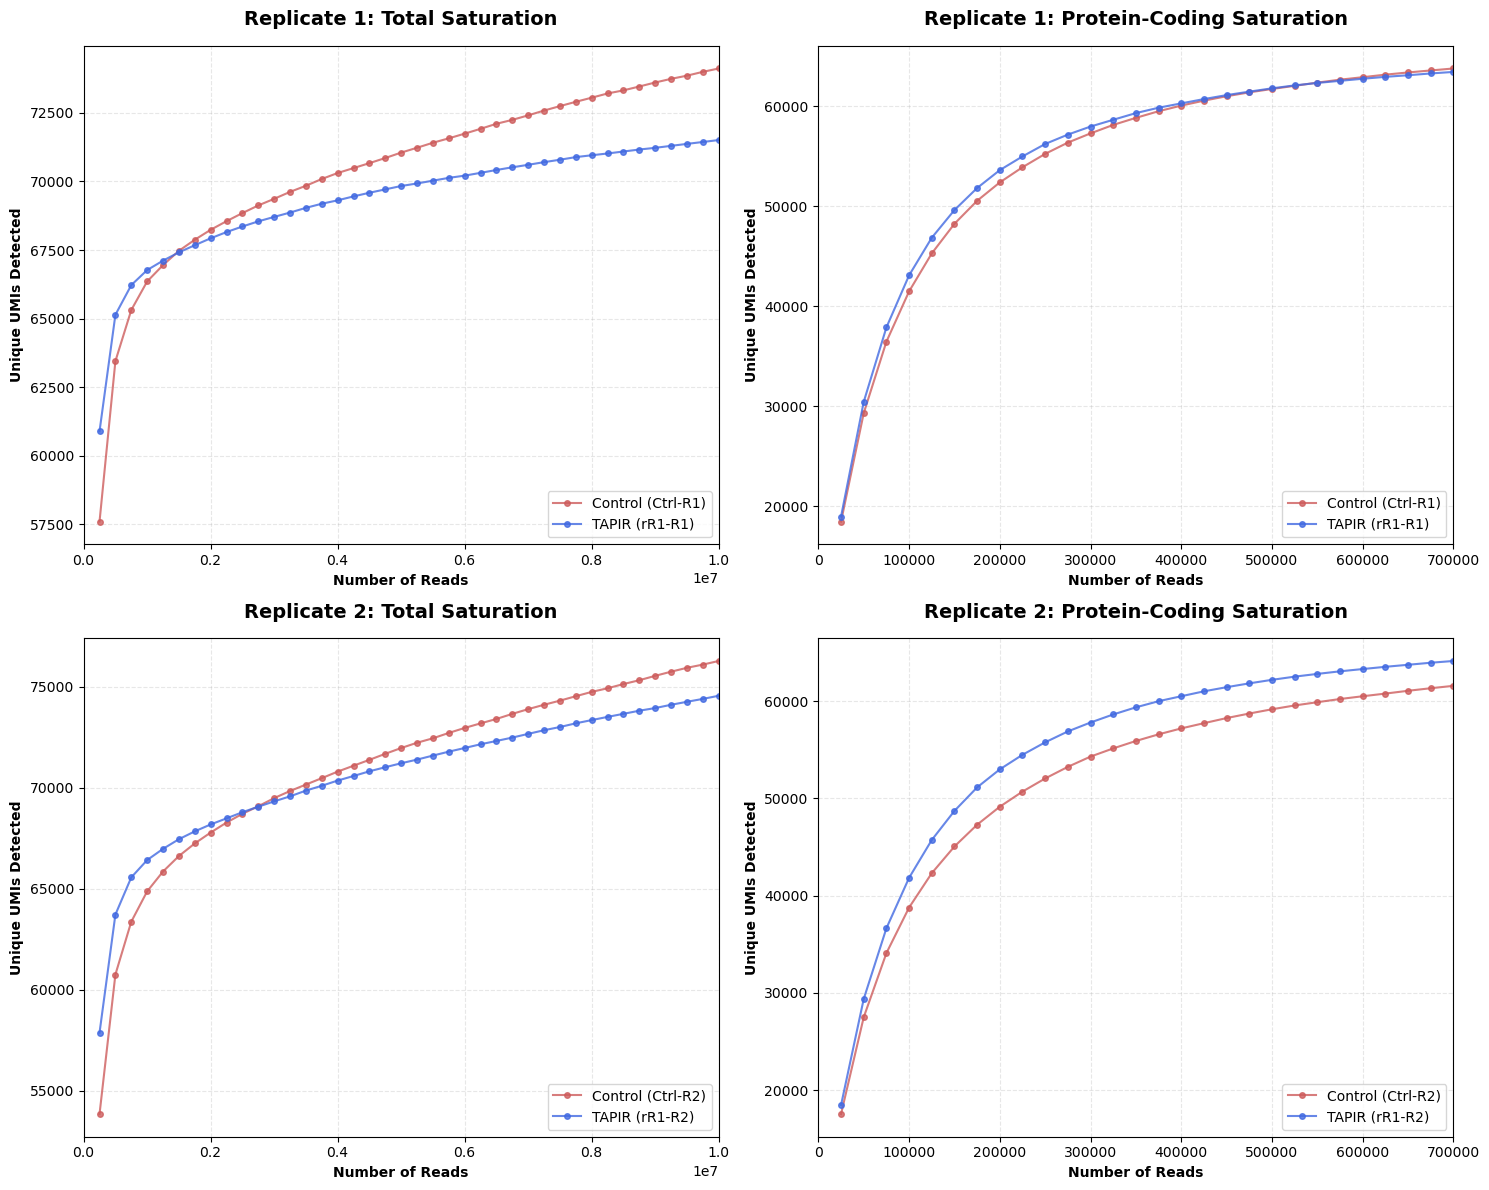

In [45]:
import matplotlib.pyplot as plt

# Your specific labels for reference
# sample_labels = ["rR1-R1", "Ctrl-R1", "rR1-R2", "Ctrl-R2"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
(ax_r1_tot, ax_r1_pc), (ax_r2_tot, ax_r2_pc) = axes

# Mapping the replicate ID to the correct subplot row
# TOTAL_MAX and PC_MAX should be defined (e.g., 10,000,000 and 700,000)
configs = [
    (ax_r1_tot, "-R1", total_results, TOTAL_MAX, "Replicate 1: Total Saturation"),
    (ax_r1_pc,  "-R1", pc_results,    PC_MAX,    "Replicate 1: Protein-Coding Saturation"),
    (ax_r2_tot, "-R2", total_results, TOTAL_MAX, "Replicate 2: Total Saturation"),
    (ax_r2_pc,  "-R2", pc_results,    PC_MAX,    "Replicate 2: Protein-Coding Saturation")
]

for ax, rep_id, res_dict, x_lim, title in configs:
    found_any = False
    
    # Sort labels so they appear in a consistent order in the legend
    for label in sorted(res_dict.keys()):
        # Matches "-R1" or "-R2"
        if rep_id in label:
            depths, detected = res_dict[label]
            
            # Color logic based on your specific sample_labels
            if "rR1" in label:
                color = 'royalblue'
                display_name = f"TAPIR ({label})"
            else:
                color = 'indianred'
                display_name = f"Control ({label})"
            
            ax.plot(depths, detected, 'o-', label=display_name, 
                    markersize=4, alpha=0.8, color=color, linewidth=1.5)
            found_any = True
    
    # Formatting each panel
    ax.set_title(title, fontweight='bold', fontsize=14, pad=15)
    ax.set_xlim(0, x_lim)
    ax.set_xlabel("Number of Reads", fontweight='bold')
    ax.set_ylabel("Unique UMIs Detected", fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if found_any:
        ax.legend(loc='lower right', frameon=True, fontsize=10)
    else:
        print(f"Warning: No data found for {rep_id} in results.")

plt.tight_layout()
plt.show()